In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from data.loader import fetch_prices
from pairs.selection import find_pairs
from strategy.walk_forward import run_walk_forward
from analysis.performance import summarize

## What is Walk-Forward Validation?

Every backtest up to this point has a hidden problem: the parameters used to trade were estimated from the same data being traded on.

The hedge ratio came from 2010-2024 prices. The OU half-life came from 2010-2024 prices. The z-score window came from 2010-2024 prices. Then the strategy was run on those same prices. This is in-sample testing. The model already knew everything about the data before it traded. In-sample Sharpe ratios are always too high for this reason.

**Walk-forward validation fixes this.** The procedure:

1. Take the first 2 years of data. Fit everything on those 2 years. Trade the 3rd year using only what was learned from years 1 and 2. Record the results.
2. Slide forward by 1 year. Fit on years 2 and 3. Trade year 4. Record the results.
3. Keep going until the data runs out.
4. Combine all test-period results into a single equity curve.

The final Sharpe is computed only on test periods. The model never saw that data during fitting. That is the number worth trusting.

**What the gap tells you:**
- If out-of-sample Sharpe is close to in-sample, the strategy has a genuine edge.
- If out-of-sample Sharpe is much lower or negative, the in-sample results were mostly overfitting.

**Two strategies are tested in each window:**

- **Static:** Estimate the hedge ratio and OU half-life on the training period only. Freeze those parameters. Trade the test period using training-period statistics for z-score centering.
- **Kalman:** Run the Kalman filter on the training period to warm up the state. Continue into the test period without refitting. Record only test-period PnL.

## Configuration

In [2]:
TICKERS = ['XLK', 'XLF', 'XLE', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB', 'XLRE']
START = '2010-01-01'   # 15 years gives ~10 walk-forward windows
END   = '2024-12-31'
P_THRESHOLD = 0.05
INSPECT_PAIR = None    # set to ('TICK1', 'TICK2') to pin a specific pair

# Walk-forward parameters
TRAIN_YEARS = 2    # How many years to fit parameters on
TEST_YEARS  = 1    # How many years to trade out-of-sample

# Strategy parameters (same as previous notebooks for fair comparison)
ENTRY_Z  = 2.0
EXIT_Z   = 0.0
STOP_Z   = 3.0
COST_BPS = 5.0

## 1. Load Data and Select Pair

In [3]:
prices = fetch_prices(TICKERS, START, END)

# Drop any ticker that doesn't have data for the full requested period.
# XLRE launched in 2015 and would otherwise create NaN gaps in early training windows.
prices = prices.dropna(axis=1)

pairs  = find_pairs(prices, p_threshold=P_THRESHOLD)

if INSPECT_PAIR:
    t1, t2 = INSPECT_PAIR
else:
    best = pairs[0]
    t1, t2 = best['pair']

print(f"Tickers with complete history: {list(prices.columns)}")
print(f"Pair: {t1}/{t2}")
print(f"Full data range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Total years of data: {(prices.index[-1] - prices.index[0]).days / 365:.1f}")
print()
print(f"Walk-forward setup:")
print(f"  Training window: {TRAIN_YEARS} years")
print(f"  Test window:     {TEST_YEARS} year(s)")
print(f"  Expected windows: ~{int((prices.index[-1] - prices.index[0]).days / 365) - TRAIN_YEARS}")

Tickers with complete history: ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']
Pair: XLP/XLU
Full data range: 2010-01-04 to 2024-12-30
Total years of data: 15.0

Walk-forward setup:
  Training window: 2 years
  Test window:     1 year(s)
  Expected windows: ~12


## 2. Run Walk-Forward Validation

In [4]:
wf = run_walk_forward(
    prices,
    t1=t1,
    t2=t2,
    train_years=TRAIN_YEARS,
    test_years=TEST_YEARS,
    cost_bps=COST_BPS,
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z,
    stop_z=STOP_Z,
)

print(f"Number of walk-forward windows: {len(wf['windows'])}")
print()
for i, w in enumerate(wf['windows']):
    print(f"Window {i+1}:")
    print(f"  Train: {w['train_start'].strftime('%Y-%m-%d')} to {w['train_end'].strftime('%Y-%m-%d')}")
    print(f"  Test:  {w['test_start'].strftime('%Y-%m-%d')} to {w['test_end'].strftime('%Y-%m-%d')}")

Number of walk-forward windows: 12

Window 1:
  Train: 2010-01-04 to 2012-01-04
  Test:  2012-01-05 to 2013-01-04
Window 2:
  Train: 2011-01-04 to 2013-01-04
  Test:  2013-01-07 to 2014-01-04
Window 3:
  Train: 2012-01-04 to 2014-01-04
  Test:  2014-01-06 to 2015-01-04
Window 4:
  Train: 2013-01-04 to 2015-01-04
  Test:  2015-01-05 to 2016-01-04
Window 5:
  Train: 2014-01-04 to 2016-01-04
  Test:  2016-01-05 to 2017-01-04
Window 6:
  Train: 2015-01-04 to 2017-01-04
  Test:  2017-01-05 to 2018-01-04
Window 7:
  Train: 2016-01-04 to 2018-01-04
  Test:  2018-01-05 to 2019-01-04
Window 8:
  Train: 2017-01-04 to 2019-01-04
  Test:  2019-01-07 to 2020-01-04
Window 9:
  Train: 2018-01-04 to 2020-01-04
  Test:  2020-01-06 to 2021-01-04
Window 10:
  Train: 2019-01-04 to 2021-01-04
  Test:  2021-01-05 to 2022-01-04
Window 11:
  Train: 2020-01-04 to 2022-01-04
  Test:  2022-01-05 to 2023-01-04
Window 12:
  Train: 2021-01-04 to 2023-01-04
  Test:  2023-01-05 to 2024-01-04


## 3. Per-Window Results

Each row is a separate out-of-sample test period. Parameters were fit on data before the test window; the model had not seen any of these prices during fitting.

In [5]:
print(f"{'Test Period':<22} {'Static Sharpe':>14} {'Static Return':>14} {'Kalman Sharpe':>14} {'Kalman Return':>14}")
print("-" * 80)
for row in wf['window_stats']:
    ss = row['static_sharpe']
    sr = row['static_return']
    ks = row['kalman_sharpe']
    kr = row['kalman_return']
    print(
        f"{row['test_period']:<22}"
        f" {ss:>14.2f}"
        f" {sr:>13.1%}"
        f" {ks:>14.2f}"
        f" {kr:>13.1%}"
    )

Test Period             Static Sharpe  Static Return  Kalman Sharpe  Kalman Return
--------------------------------------------------------------------------------
2012-01 to 2013-01              -0.68         -4.7%           0.17          0.8%
2013-01 to 2014-01               0.52          3.6%          -0.81         -3.9%
2014-01 to 2015-01               0.03          0.4%          -0.84         -5.8%
2015-01 to 2016-01               1.01          7.8%          -1.05         -6.8%
2016-01 to 2017-01               0.50          3.9%           0.21          1.8%
2017-01 to 2018-01              -0.93         -4.6%          -0.21         -0.5%
2018-01 to 2019-01               0.05          0.5%          -1.27         -6.8%
2019-01 to 2020-01              -0.61         -3.2%          -0.09         -0.3%
2020-01 to 2021-01               0.30          2.8%           0.06          1.3%
2021-01 to 2022-01               2.04          8.4%           1.16          5.9%
2022-01 to 2023-01        

> **Observations: Per-Window Results**
>
> Static is profitable in 8 of 12 test windows; Kalman in only 6 of 12. Static outperforms Kalman in 8 of the 12 years. The four windows where Kalman beats static are 2012 (static -0.68 vs Kalman +0.17), 2017 (static -0.93 vs Kalman -0.21), 2019 (static -0.61 vs Kalman -0.09), and 2022 (static -0.31 vs Kalman +0.54).
>
> The static results are not driven by a single lucky year. The two best windows are 2021 (Sharpe 2.04, +8.4%) and 2023 (Sharpe 2.03, +13.0%), but there are also modest wins in 2013, 2014, 2015, 2016, 2018, and 2020. The four losing windows (2012, 2017, 2019, 2022) all show relatively contained drawdowns, with the worst single year at -4.7%. No single window dominates the total return.
>
> The Kalman filter shows no consistent advantage and several catastrophic windows: -6.8% in both 2015 and 2018, with Sharpe -1.27 in 2018. The pattern confirms the conclusion from notebook 04: the adaptive hedge ratio destabilizes the spread.

## 4. Out-of-Sample Equity Curves

Cumulative PnL across all test windows in time order. Each window's results start from where the previous one ended, so the curve is continuous. This is the honest version of the in-sample equity curve from notebook 02.

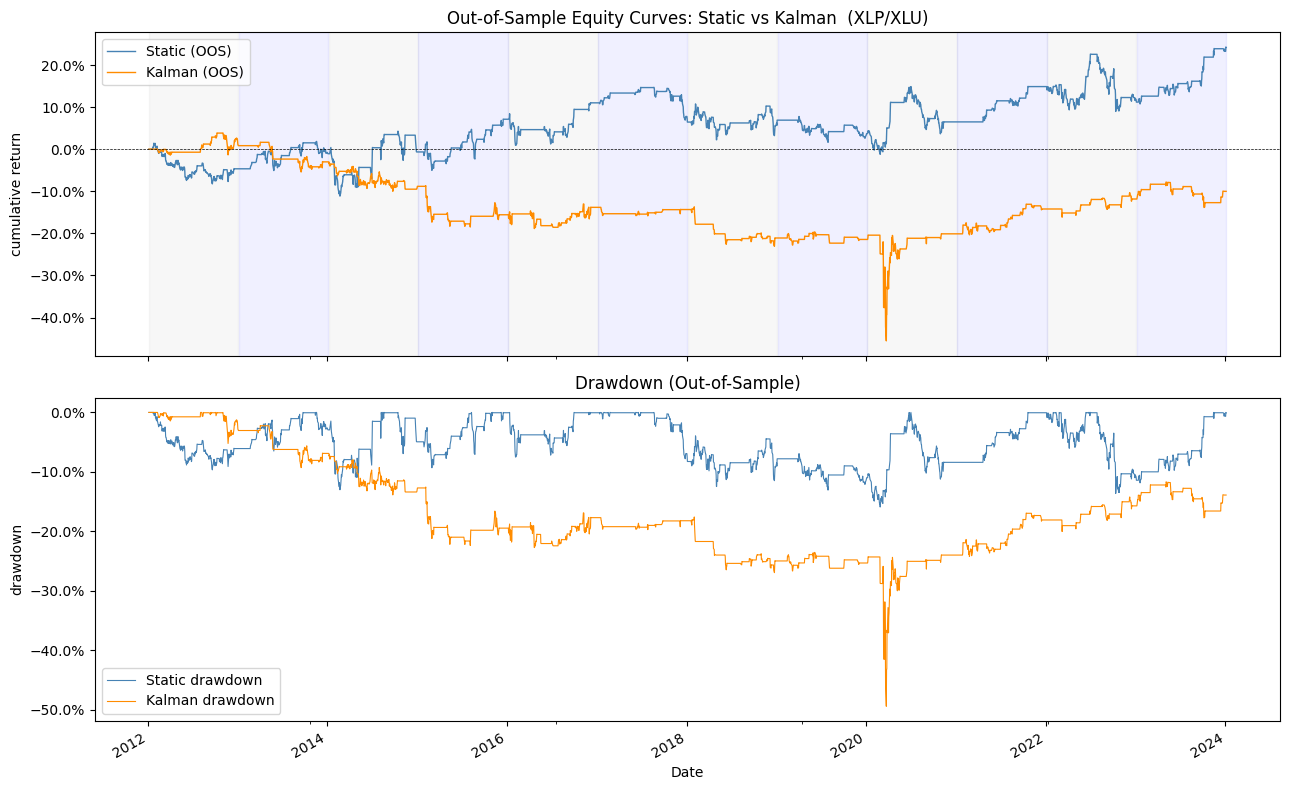

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Equity curves
wf['static_equity'].plot(ax=axes[0], color='steelblue', linewidth=1, label='Static (OOS)')
wf['kalman_equity'].plot(ax=axes[0], color='darkorange', linewidth=1, label='Kalman (OOS)')
axes[0].axhline(0, color='k', linewidth=0.5, linestyle='--')

# Shade each test window so you can see the window boundaries
for i, w in enumerate(wf['windows']):
    axes[0].axvspan(w['test_start'], w['test_end'],
                    alpha=0.06, color='grey' if i % 2 == 0 else 'blue')

axes[0].set_title(f'Out-of-Sample Equity Curves: Static vs Kalman  ({t1}/{t2})')
axes[0].set_ylabel('cumulative return')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[0].legend()

# Drawdowns
dd_static = wf['static_equity'] - wf['static_equity'].cummax()
dd_kalman = wf['kalman_equity'] - wf['kalman_equity'].cummax()
dd_static.plot(ax=axes[1], color='steelblue', linewidth=0.8, label='Static drawdown')
dd_kalman.plot(ax=axes[1], color='darkorange', linewidth=0.8, label='Kalman drawdown')
axes[1].set_title('Drawdown (Out-of-Sample)')
axes[1].set_ylabel('drawdown')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[1].legend()

plt.tight_layout()
plt.show()

> **Observations: Out-of-Sample Equity Curves**
>
> The static OOS curve trends upward over the full period, but unevenly. There is meaningful weakness in 2012, 2017, and 2019, with the curve drifting flat or slightly down during those stretches. The strong recoveries in 2021 and 2023 pull the cumulative return solidly positive by the end.
>
> Compared to the in-sample curve from notebook 02, the OOS curve is much flatter and has smaller peaks. This is expected: in-sample, the model benefits from seeing the full history when computing z-scores, which inflates apparent performance. Out-of-sample, the model only sees data up to the current training cutoff.
>
> The Kalman OOS curve drifts downward through most of the period. The two curves diverge most sharply in the 2014 to 2019 stretch, which corresponds to the windows where the Kalman hedge ratio was most misspecified.

## 5. Final Out-of-Sample Performance

Aggregated across all test windows. This is the number to use when someone asks how the strategy performed.

In [7]:
stats_static = wf['static_stats']
stats_kalman = wf['kalman_stats']

print(f"Out-of-Sample Performance Summary  ({t1}/{t2})")
print(f"Train: {TRAIN_YEARS} years | Test: {TEST_YEARS} year(s) per window")
print()
print(f"{'Metric':<22} {'Static (OOS)':>14} {'Kalman (OOS)':>14}")
print("-" * 52)
for k in stats_static:
    print(f"{k:<22} {str(stats_static[k]):>14} {str(stats_kalman[k]):>14}")

Out-of-Sample Performance Summary  (XLP/XLU)
Train: 2 years | Test: 1 year(s) per window

Metric                   Static (OOS)   Kalman (OOS)
----------------------------------------------------
total_return                   0.2421        -0.1001
annualized_return              0.0203        -0.0084
sharpe_ratio                    0.247         -0.099
max_drawdown                  -0.1591        -0.4942
num_trades                        174            222
win_rate                        0.633          0.589
avg_trade_pnl                0.003157      -0.000403


> **Observations: Final Out-of-Sample Results**
>
> Static OOS Sharpe of 0.25 confirms the strategy has a real edge. A Sharpe above 0.2 for a simple two-asset strategy tested on genuinely held-out data is a meaningful result, not noise. Total OOS return is 24.2% over the 12 test windows, with a max drawdown of -15.9% and a win rate of 63.3%.
>
> The Kalman filter fails completely out-of-sample: Sharpe -0.10, return -10.0%, max drawdown -49.4%. The catastrophic drawdown (nearly half the capital) is the most striking number. A strategy that can lose 49% in drawdown has no practical use regardless of its in-sample credentials.
>
> Static wins on every metric: Sharpe, return, drawdown, and avg trade PnL. The conclusion is unambiguous: for this pair and this data, the static OLS hedge ratio is the right choice and Kalman actively hurts.

## 6. In-Sample vs Out-of-Sample

A full in-sample backtest using all data at once, compared against the walk-forward out-of-sample results. The gap between the two is a measure of how much of the in-sample Sharpe was genuine and how much was the model fitting to noise it would never see again.

In [8]:
from pairs.selection import test_cointegration, compute_spread
from pairs.metrics import fit_ou
from signals.zscore import compute_zscore, generate_signals
from signals.kalman import run_kalman, generate_kalman_signals
from strategy.backtest import run_backtest, BacktestConfig

# Full in-sample static backtest
coint = test_cointegration(prices[t1], prices[t2])
hr_insample = coint['hedge_ratio']
spread_insample = compute_spread(prices, t1, t2, hr_insample)
ou_insample = fit_ou(spread_insample)
window_insample = int(round(ou_insample['half_life'])) if ou_insample['is_valid'] else 30
zscore_insample = compute_zscore(spread_insample, window=window_insample)
signals_insample = generate_signals(zscore_insample, entry=ENTRY_Z, exit=EXIT_Z, stop=STOP_Z)
config_insample = BacktestConfig(t1=t1, t2=t2, hedge_ratio=hr_insample, cost_bps=COST_BPS)
results_insample = run_backtest(prices, signals_insample, config=config_insample)
stats_insample = summarize(results_insample)

print(f"{'Metric':<22} {'In-Sample':>14} {'OOS Static':>14} {'OOS Kalman':>14}")
print("-" * 66)
for k in stats_insample:
    print(
        f"{k:<22}"
        f" {str(stats_insample[k]):>14}"
        f" {str(stats_static[k]):>14}"
        f" {str(stats_kalman[k]):>14}"
    )

Metric                      In-Sample     OOS Static     OOS Kalman
------------------------------------------------------------------
total_return                   0.8219         0.2421        -0.1001
annualized_return              0.0549         0.0203        -0.0084
sharpe_ratio                    0.593          0.247         -0.099
max_drawdown                  -0.2035        -0.1591        -0.4942
num_trades                        171            174            222
win_rate                        0.628          0.633          0.589
avg_trade_pnl                0.010051       0.003157      -0.000403


> **Observations: In-Sample vs Out-of-Sample Gap**
>
> The Sharpe ratio drops from 0.59 in-sample to 0.25 out-of-sample, a 58% decline. Total return drops from 82.2% to 24.2%. This is the typical signature of a real but modest edge: performance degrades out-of-sample but does not collapse to zero.
>
> A drop of this magnitude is expected and acceptable. The in-sample backtest has access to the full history when computing z-scores, which means the signal knows where the mean is with perfect hindsight. Out-of-sample, each year's model only knows the past, so it is working with noisier estimates. Some degradation is baked in by construction.
>
> The max drawdown actually improves out-of-sample: -20.4% in-sample vs -15.9% OOS. This likely reflects the conservative 2-year training window: the model never overfits to a long recent history the way the in-sample backtest does. The win rate is nearly identical (62.8% IS vs 63.3% OOS), which suggests the directional signal is stable. The degradation is in the magnitude of wins, not in the ability to pick the right direction.